In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Regression models
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

# Classification model
from sklearn.linear_model import LogisticRegression

# Metrics
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

In [31]:
df = pd.read_csv('/content/drive/MyDrive/AIML_LAB/min_project /loan_data.csv')   # change path if needed

# Fix column names
df.columns = df.columns.str.strip()

print("\nDataset Loaded")
print("Columns:", df.columns)
print("Shape:", df.shape)
print(df.head())


Dataset Loaded
Columns: Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')
Shape: (45000, 14)
   person_age person_gender person_education  person_income  person_emp_exp  \
0        22.0        female           Master        71948.0               0   
1        21.0        female      High School        12282.0               0   
2        25.0        female      High School        12438.0               3   
3        23.0        female         Bachelor        79753.0               0   
4        24.0          male           Master        66135.0               1   

  person_home_ownership  loan_amnt loan_intent  loan_int_rate  \
0                  RENT    35000.0    PERSONAL          16.02   
1                   OWN   

In [32]:
print("\nStep 3: EDA")

print("Missing Values:\n", df.isnull().sum())

print("\nStatistical Info:")
print(df.describe())


Step 3: EDA
Missing Values:
 person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

Statistical Info:
         person_age  person_income  person_emp_exp     loan_amnt  \
count  45000.000000   4.500000e+04    45000.000000  45000.000000   
mean      27.764178   8.031905e+04        5.410333   9583.157556   
std        6.045108   8.042250e+04        6.063532   6314.886691   
min       20.000000   8.000000e+03        0.000000    500.000000   
25%       24.000000   4.720400e+04        1.000000   5000.000000   
50%       26.000000   6.70

In [33]:
print(df.columns)

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')


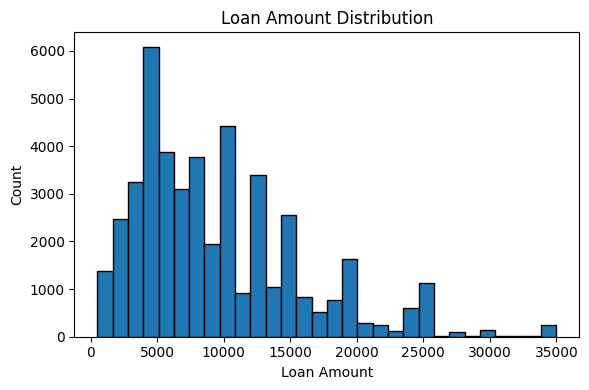

In [34]:
plt.figure(figsize=(6,4))
plt.hist(df['loan_amnt'], bins=30, edgecolor='black')
plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

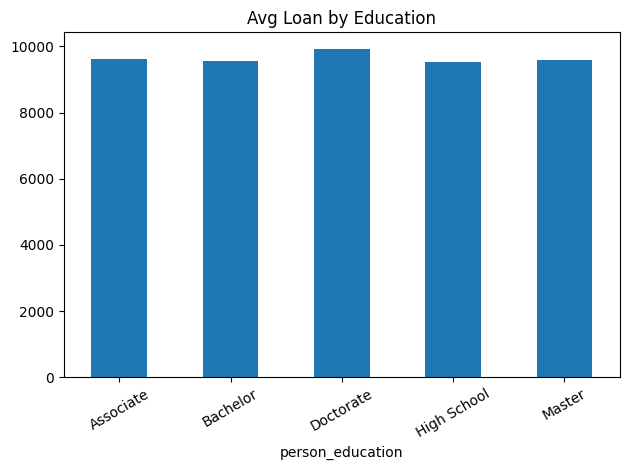

In [35]:
df.groupby('person_education')['loan_amnt'].mean().plot(kind='bar')

plt.title('Avg Loan by Education')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [36]:
# Drop missing values
df.dropna(inplace=True)

# Convert categorical → numeric
df_enc = pd.get_dummies(df, drop_first=True)

# Features & Target
X = df_enc.drop('loan_amnt', axis=1)
y = df_enc['loan_amnt']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nPreprocessing Complete")
print("Train size:", len(X_train), "| Test size:", len(X_test))


Preprocessing Complete
Train size: 36000 | Test size: 9000


In [37]:
models = {
    'Linear Regression': LinearRegression(),
    'Lasso (L1)': Lasso(alpha=0.1, max_iter=10000),
    'Ridge (L2)': Ridge(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(max_depth=6, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf', C=10),
    'KNN': KNeighborsRegressor(n_neighbors=5),
}

print("\nStep 5 Done:", len(models), "models defined")


Step 5 Done: 8 models defined


In [38]:
rmse_scores = {}
r2_scores = {}

print("\nModel Performance:")
print("-"*40)

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    rmse_scores[name] = rmse
    r2_scores[name] = r2

    print(f"{name}: RMSE={rmse:.0f}, R2={r2:.4f}")


Model Performance:
----------------------------------------
Linear Regression: RMSE=4007, R2=0.6011
Lasso (L1): RMSE=4007, R2=0.6011
Ridge (L2): RMSE=4007, R2=0.6011
Decision Tree: RMSE=1333, R2=0.9559
Random Forest: RMSE=266, R2=0.9982
Gradient Boosting: RMSE=487, R2=0.9941
SVR: RMSE=5016, R2=0.3750
KNN: RMSE=4390, R2=0.5213


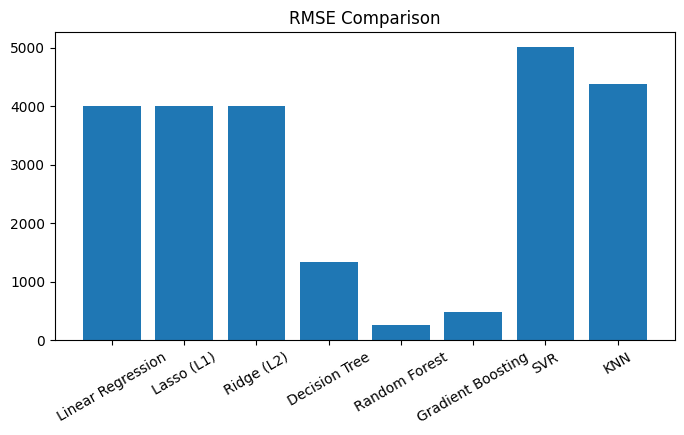

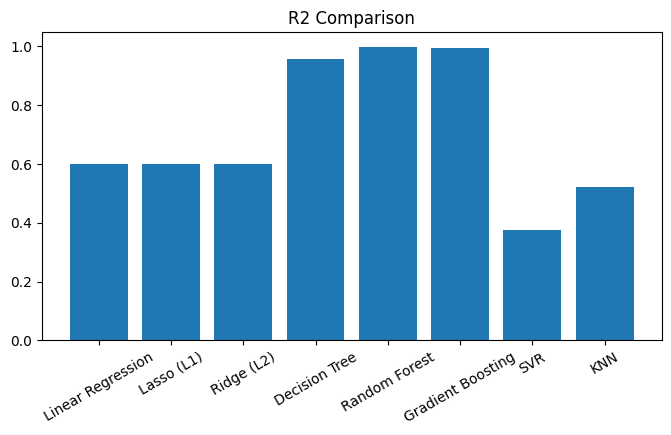

In [39]:
# RMSE
plt.figure(figsize=(8,4))
plt.bar(rmse_scores.keys(), rmse_scores.values())
plt.xticks(rotation=30)
plt.title("RMSE Comparison")
plt.show()

# R2
plt.figure(figsize=(8,4))
plt.bar(r2_scores.keys(), r2_scores.values())
plt.xticks(rotation=30)
plt.title("R2 Comparison")
plt.show()

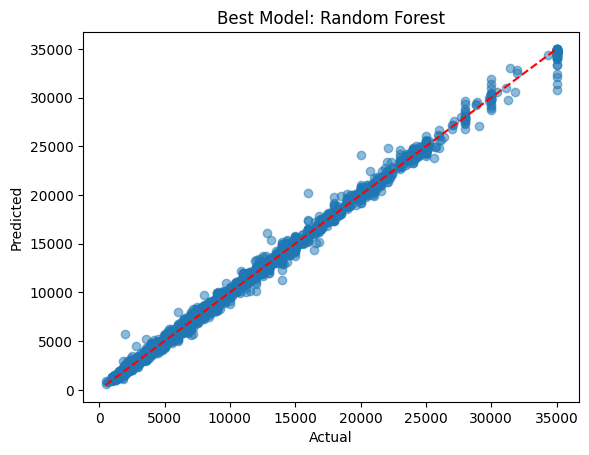

In [40]:
best_model_name = max(r2_scores, key=r2_scores.get)
best_model = models[best_model_name]

pred = best_model.predict(X_test)

plt.scatter(y_test, pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.title(f"Best Model: {best_model_name}")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [41]:
sorted_models = sorted(r2_scores.items(), key=lambda x: x[1], reverse=True)

print("\nFINAL RANKING:")
for i, (name, r2) in enumerate(sorted_models, 1):
    print(f"{i}. {name} | RMSE={rmse_scores[name]:.0f} | R2={r2:.4f}")

print("\nBest Model:", best_model_name)


FINAL RANKING:
1. Random Forest | RMSE=266 | R2=0.9982
2. Gradient Boosting | RMSE=487 | R2=0.9941
3. Decision Tree | RMSE=1333 | R2=0.9559
4. Linear Regression | RMSE=4007 | R2=0.6011
5. Lasso (L1) | RMSE=4007 | R2=0.6011
6. Ridge (L2) | RMSE=4007 | R2=0.6011
7. KNN | RMSE=4390 | R2=0.5213
8. SVR | RMSE=5016 | R2=0.3750

Best Model: Random Forest


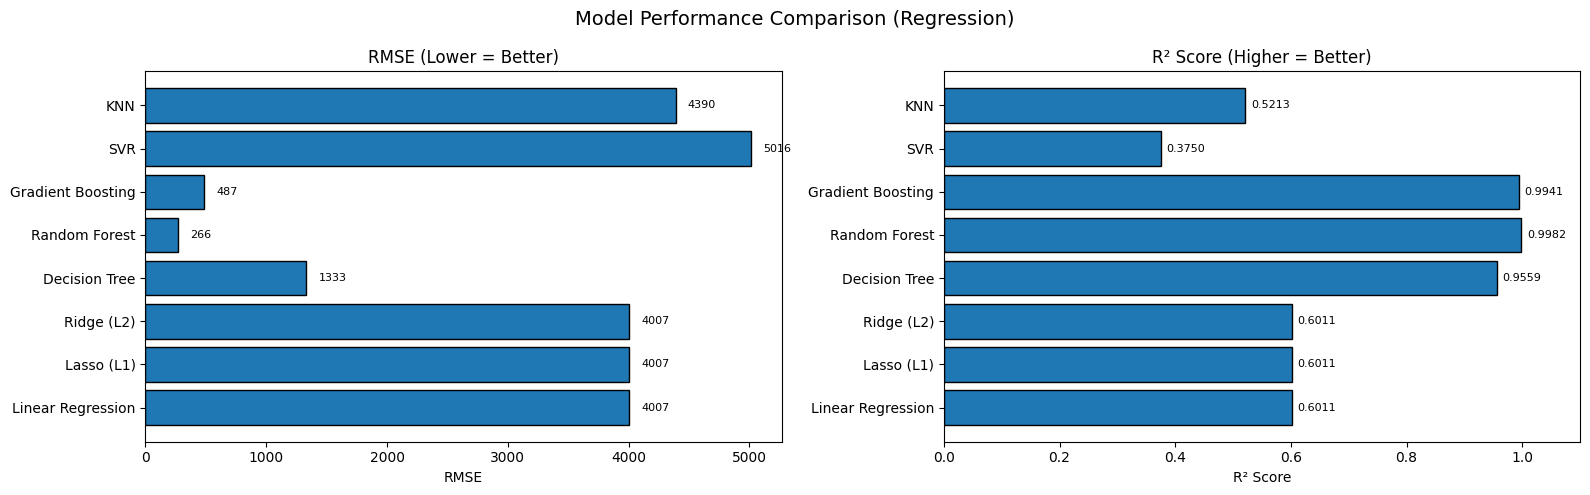

In [42]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- RMSE Chart ---
axes[0].barh(
    list(rmse_scores.keys()),
    list(rmse_scores.values()),
    edgecolor='black'
)
axes[0].set_title('RMSE (Lower = Better)')
axes[0].set_xlabel('RMSE')

# Add values
for i, v in enumerate(rmse_scores.values()):
    axes[0].text(v + 100, i, f'{v:.0f}', va='center', fontsize=8)

# --- R² Chart ---
axes[1].barh(
    list(r2_scores.keys()),
    list(r2_scores.values()),
    edgecolor='black'
)
axes[1].set_title('R² Score (Higher = Better)')
axes[1].set_xlabel('R² Score')
axes[1].set_xlim(0, 1.1)

# Add values
for i, v in enumerate(r2_scores.values()):
    axes[1].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=8)

# --- Final Layout ---
plt.suptitle('Model Performance Comparison (Regression)', fontsize=14)
plt.tight_layout()
plt.show()

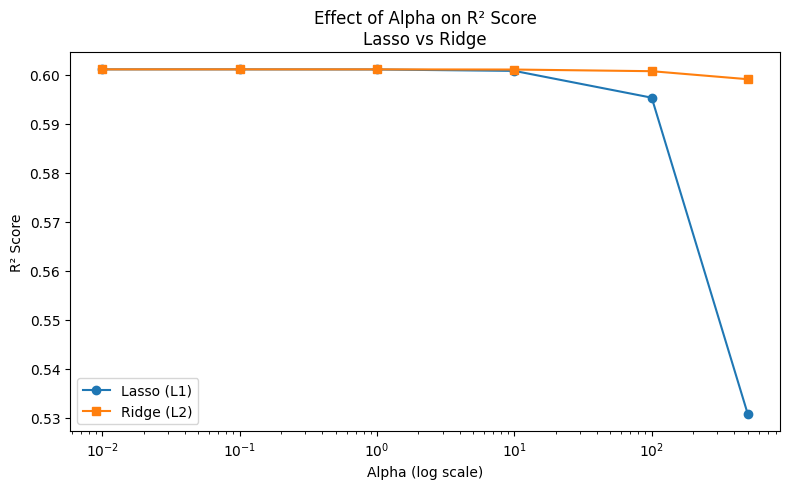

In [43]:
from sklearn.linear_model import Lasso, Ridge

alphas = [0.01, 0.1, 1, 10, 100, 500]

lasso_r2 = []
ridge_r2 = []

for a in alphas:
    # Lasso (increase max_iter to avoid warning)
    lasso = Lasso(alpha=a, max_iter=20000)
    lasso.fit(X_train, y_train)
    lasso_pred = lasso.predict(X_test)
    lasso_r2.append(r2_score(y_test, lasso_pred))

    # Ridge
    ridge = Ridge(alpha=a)
    ridge.fit(X_train, y_train)
    ridge_pred = ridge.predict(X_test)
    ridge_r2.append(r2_score(y_test, ridge_pred))


# --- Plot ---
plt.figure(figsize=(8,5))

plt.plot(alphas, lasso_r2, marker='o', label='Lasso (L1)')
plt.plot(alphas, ridge_r2, marker='s', label='Ridge (L2)')

plt.xscale('log')
plt.title('Effect of Alpha on R² Score\nLasso vs Ridge')
plt.xlabel('Alpha (log scale)')
plt.ylabel('R² Score')
plt.legend()

plt.tight_layout()
plt.show()

In [44]:
print("\n" + "*" * 50)
print("      FINAL MODEL RESULTS (Loan Project)")
print("   (Ranked by R² Score — Higher is Better)")
print("*" * 50)

print(f"{'Rank':<5} {'Model':<22} {'RMSE':>10} {'R²':>10}")
print("-" * 50)

# Sort models by R² (descending)
sorted_models = sorted(r2_scores.items(), key=lambda x: x[1], reverse=True)

for rank, (name, r2) in enumerate(sorted_models, 1):
    rmse = rmse_scores[name]

    if rank == 1:
        tag = " (BEST!)"
    elif rank == len(sorted_models):
        tag = " (WORST)"
    else:
        tag = ""

    print(f"{rank:<5} {name:<22} {rmse:>10,.0f} {r2:>10.4f}{tag}")

# Best model
best_model_name = sorted_models[0][0]

print("\nBest Model is:", best_model_name)
print(f"R² Score   : {r2_scores[best_model_name]:.4f}")
print(f"RMSE Value : {rmse_scores[best_model_name]:,.0f}")


**************************************************
      FINAL MODEL RESULTS (Loan Project)
   (Ranked by R² Score — Higher is Better)
**************************************************
Rank  Model                        RMSE         R²
--------------------------------------------------
1     Random Forest                 266     0.9982 (BEST!)
2     Gradient Boosting             487     0.9941
3     Decision Tree               1,333     0.9559
4     Linear Regression           4,007     0.6011
5     Lasso (L1)                  4,007     0.6011
6     Ridge (L2)                  4,007     0.6011
7     KNN                         4,390     0.5213
8     SVR                         5,016     0.3750 (WORST)

Best Model is: Random Forest
R² Score   : 0.9982
RMSE Value : 266


In [45]:
import pickle

# Save model
with open('best_loan_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

print(f"Best model ('{best_model_name}') saved successfully!")

Best model ('Random Forest') saved successfully!
